# TIPE


## Requirements and Settings

In [2]:
import os
import uuid
import cv2
from PIL import Image, ImageDraw

## Dataset load

In [3]:
import tensorflow as tf
import json
import numpy as np
import matplotlib.pyplot as plt

In [5]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg', shuffle=False)

In [6]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

def load_im_mask(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_png(byte_img)
    return img

In [7]:
images = images.map(load_image)

In [ ]:
# images.as_numpy_iterator().next()

In [8]:
image_generator = images.batch(4).as_numpy_iterator()

In [9]:
plot_images = image_generator.next()

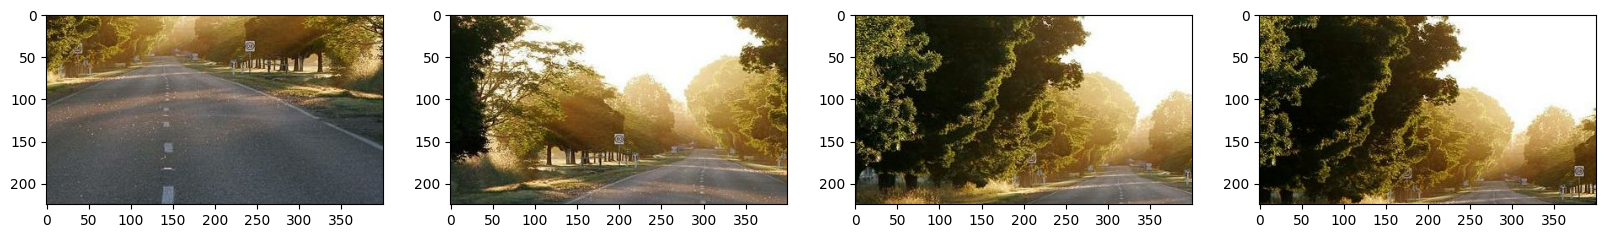

In [10]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image)
plt.show()

## Data Split

In [ ]:
# Here split images into three folders: train / test / val
# Need enough amount of images
# 70% for train, 15% for each test and val

In [ ]:
# for folder in  ['train', 'test', 'val']:
#     for file in os.listdir(os.path.join('data', folder, 'images')):
#         filename = file.split('.')[0]+'.json'
#         existing_filepath = os.path.join('data', 'labels', filename)
#         if os.path.exists(existing_filepath):
#             new_filepath = os.path.join('data',folder,'labels',filename)
#             os.replace(existing_filepath, new_filepath)

## Augmentation

In [46]:
import albumentations as alb

In [47]:
augmentor = alb.Compose([alb.RandomCrop(width=400, height=225), alb.HorizontalFlip(p=0.5), alb.RandomBrightnessContrast(p=0.2), alb.RandomGamma(p=0.2)])

In [14]:
image = plt.imread(os.path.join('data', 'images', '5f07a2b6-b9bf-11ed-9af5-dc41a9ef7148.png'))
mask = plt.imread(os.path.join('data', 'masks', '5f07a2b6-b9bf-11ed-9af5-dc41a9ef7148.png'))

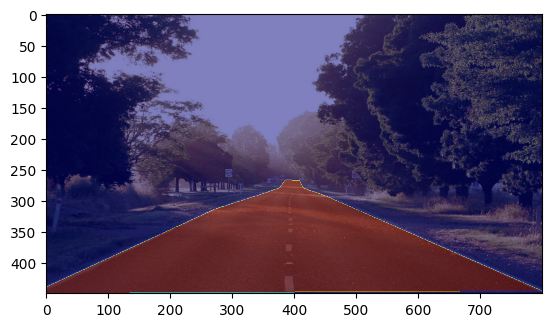

In [15]:
plt.imshow(image)
plt.imshow(mask, cmap='jet', alpha=0.5)

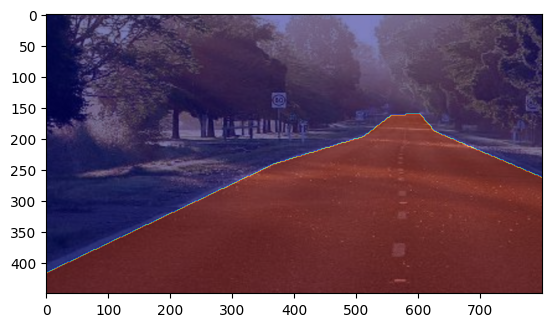

In [ ]:
transformed = augmentor(image=image, mask=mask)
newim=cv2.resize(transformed['image'], dsize=(800,450))
newmask=cv2.resize(transformed['mask'], dsize=(800,450))
plt.imshow(newim)
plt.imshow(newmask, cmap='jet', alpha=0.5)
plt.imsave('test.png', newmask, cmap='gray')

In [49]:
for file in os.listdir(os.path.join('data', 'images')):
    filename = file.split('.')[0]
    image = plt.imread(os.path.join('data', 'images', file))
    mask = plt.imread(os.path.join('data', 'masks', filename+'.png'))
    for i in range(500):
        transformed = augmentor(image=image, mask=mask)
        plt.imsave(os.path.join('data', 'images', filename+ '.' + str(i) +'.jpg'), transformed['image'])
        plt.imsave(os.path.join('data', 'masks', filename+'.' + str(i) +'.png'), transformed['mask'], cmap='gray')

## Datasets

In [11]:
train_images = tf.data.Dataset.list_files('data\\images\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (104,184)))
train_images = train_images.map(lambda x: x/255)

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


In [ ]:
# do the same for tests and validations

In [ ]:
# train_images.as_numpy_iterator().next()

In [12]:
def load_masks (img) :
    ret= np.zeros((img.shape[0], img.shape[1]))
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i,j,0] == 1:
                ret[i,j] = 1
    return ret

In [13]:
train_masks = tf.data.Dataset.list_files('data\\masks\\*.png', shuffle=False)
train_masks = train_masks.map(load_im_mask)
# train_masks = train_masks.map(lambda x: tf.image.rgb_to_grayscale(x))
train_masks = train_masks.map(lambda x: tf.image.resize(x, (104,184)))
train_masks = train_masks.map(lambda x: x//255)

In [14]:
# do the same for test and validations
train_masks.as_numpy_iterator().next().shape

(104, 184, 1)

In [90]:
len(train_images),len(train_masks)

(501, 501)

In [15]:
train = tf.data.Dataset.zip((train_images, train_masks))
train = train.shuffle(3*len(train_images))
train = train.batch(8)
train = train.prefetch(4)

In [136]:
train

<PrefetchDataset element_spec=(TensorSpec(shape=(None, 104, 184, None), dtype=tf.float32, name=None), TensorSpec(shape=(None, 104, 184, None), dtype=tf.float32, name=None))>

In [ ]:
# do the same for test and validations

In [137]:
train.as_numpy_iterator().next()[0].shape

(8, 104, 184, 3)

In [138]:
data_samples = train.as_numpy_iterator()

In [139]:
res = data_samples.next()

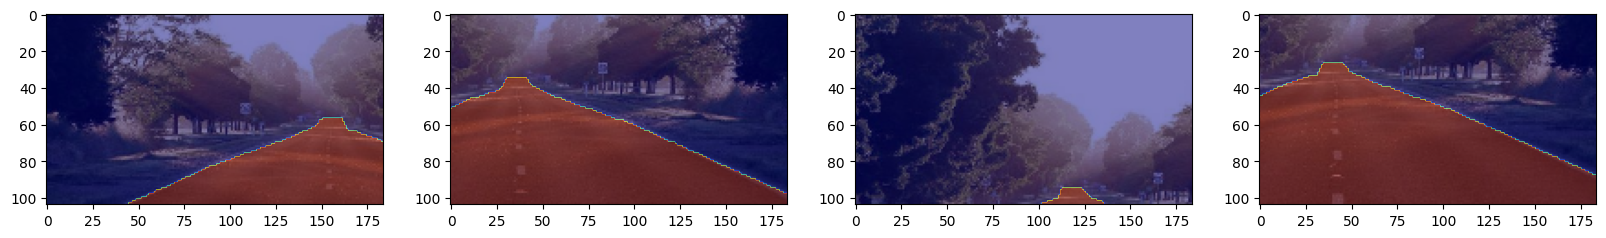

In [140]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    image=res[0][idx]
    mask=res[1][idx]
    ax[idx].imshow(image)
    ax[idx].imshow(mask, cmap='jet', alpha=0.5)
plt.show()

## Deep Learning

In [141]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv3D, Dense, GlobalMaxPooling2D, GlobalMaxPooling3D, UpSampling2D, MaxPool2D, MaxPooling2D, Dropout, Concatenate

In [142]:
def build_model():
    input_shape = (104, 184, 3)

    # Define the input layer
    inputs = Input(input_shape)

    # Encoder
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D((2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D((2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D((2, 2))(conv3)

    # Decoder
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    drop4 = Dropout(0.5)(conv4)
    up5 = UpSampling2D((2, 2))(drop4)
    up5 = Conv2D(128, (3, 3), activation='relu', padding='same')(up5)
    concat5 = Concatenate()([conv3, up5])

    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(concat5)
    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv5)
    up6 = UpSampling2D((2, 2))(conv5)
    up6 = Conv2D(64, (3, 3), activation='relu', padding='same')(up6)
    concat6 = Concatenate()([conv2, up6])

    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(concat6)
    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv6)
    up7 = UpSampling2D((2, 2))(conv6)
    up7 = Conv2D(32, (3, 3), activation='relu', padding='same')(up7)
    concat7 = Concatenate()([conv1, up7])

    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(concat7)
    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv7)

    # Output layer
    output = Conv2D(1, (1, 1), activation='sigmoid')(conv7)
    
    # Create the model
    model = Model(inputs=inputs, outputs=output)
    return model

In [143]:
roadmodel = build_model()

In [144]:
roadmodel.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 104, 184, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_141 (Conv2D)            (None, 104, 184, 32  896         ['input_12[0][0]']               
                                )                                                                 
                                                                                                  
 conv2d_142 (Conv2D)            (None, 104, 184, 32  9248        ['conv2d_141[0][0]']             
                                )                                                           

In [145]:
X, Y = train.as_numpy_iterator().next()

In [ ]:
masks = roadmodel.predict(X)

## Losses and Optimizers

In [146]:
from tensorflow.keras.optimizers.legacy import Adam

In [147]:
batches_per_epoch = len(train)
lr_decay = (1./0.75 -1)/batches_per_epoch

In [148]:
optimizer = Adam(learning_rate=0.0001, decay=lr_decay)

In [149]:
loss_fn = tf.keras.losses.BinaryCrossentropy()

In [41]:
loss_fn(Y, masks).numpy()

NameError: name 'masks' is not defined

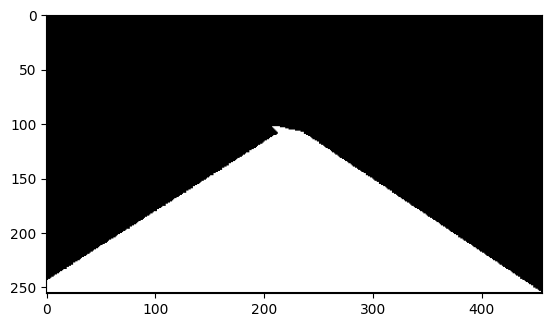

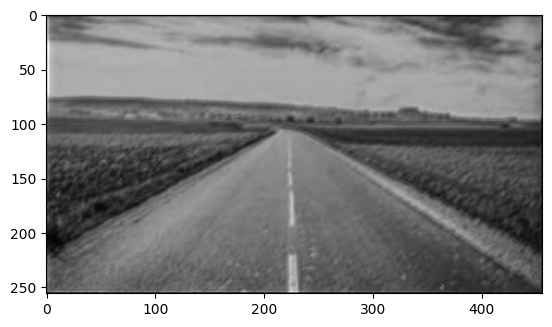

In [ ]:
plt.figure(0)
plt.imshow(Y[1], cmap="gray")
plt.figure(1)
plt.imshow(masks[1], cmap="gray")
plt.show()

## Training

In [150]:
roadmodel.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [151]:
logdir='logs'

In [152]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [153]:
hist = roadmodel.fit(train, epochs=10, callbacks=[tensorboard_callback])

Epoch 1/10
63/63 [==============================] - 155s 2s/step - loss: 0.3990 - accuracy: 0.8416
Epoch 2/10
63/63 [==============================] - 130s 2s/step - loss: 0.1712 - accuracy: 0.8416
Epoch 3/10
63/63 [==============================] - 126s 2s/step - loss: 0.1333 - accuracy: 0.9067
Epoch 4/10
63/63 [==============================] - 134s 2s/step - loss: 0.1182 - accuracy: 0.9835
Epoch 5/10
63/63 [==============================] - 134s 2s/step - loss: 0.0600 - accuracy: 0.9822
Epoch 6/10
63/63 [==============================] - 136s 2s/step - loss: 0.0356 - accuracy: 0.9866
Epoch 7/10
63/63 [==============================] - 136s 2s/step - loss: 0.0306 - accuracy: 0.9880
Epoch 8/10
63/63 [==============================] - 133s 2s/step - loss: 0.0273 - accuracy: 0.9892
Epoch 9/10
63/63 [==============================] - 111s 2s/step - loss: 0.0242 - accuracy: 0.9903
Epoch 10/10
63/63 [==============================] - 109s 2s/step - loss: 0.0220 - accuracy: 0.9914


In [154]:
hist.history

{'loss': [0.3989757001399994,
  0.17121586203575134,
  0.1333291083574295,
  0.11819174885749817,
  0.06000509858131409,
  0.03556743264198303,
  0.030550271272659302,
  0.027272185310721397,
  0.024179456755518913,
  0.022041887044906616],
 'accuracy': [0.8415904641151428,
  0.8415906429290771,
  0.9067043662071228,
  0.9835224747657776,
  0.98215252161026,
  0.9865884780883789,
  0.9880393147468567,
  0.9892154335975647,
  0.9902640581130981,
  0.9913981556892395]}

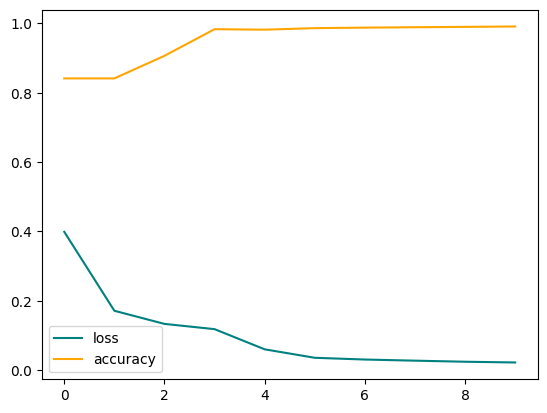

In [155]:
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['accuracy'], color='orange', label='accuracy')
plt.legend()
plt.show()

In [19]:
test_sample = train.as_numpy_iterator().next() #replace with test instead of train
# image = plt.imread(os.path.join('data', 'images', '1d6081ab-b9c3-11ed-a745-dc41a9ef7148.jpg'))
# image = tf.image.resize(image, (104,184))

In [45]:
yhat = load_model.predict(test_sample[0])

1/1 [==============================] - 0s 360ms/step


(8, 104, 184, 3)

In [171]:
yhat.shape

(1, 104, 184, 1)

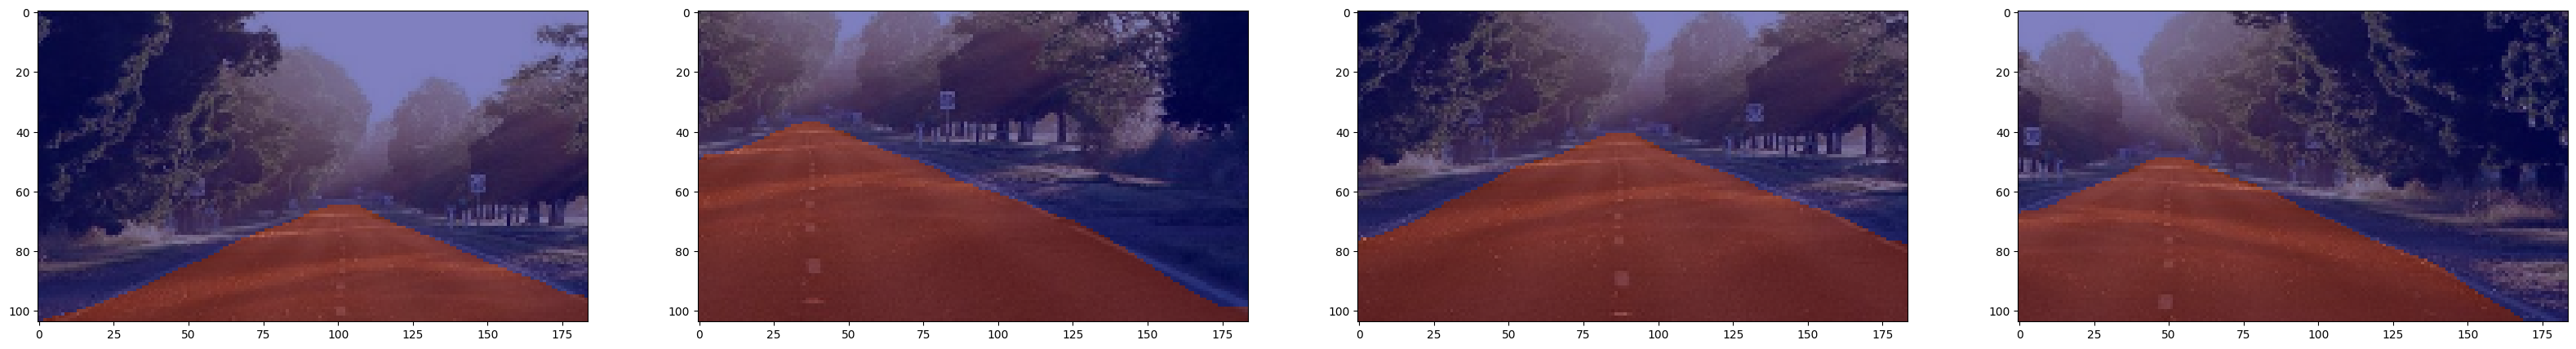

In [21]:
fig, ax = plt.subplots(ncols=4, figsize=(40,20))
for idx in range(4):
    image=test_sample[0][idx]
    mask=yhat[idx]
    ax[idx].imshow(image)
    ax[idx].imshow(np.round(mask), cmap='jet', alpha=0.5)
plt.show()

In [43]:
# plt.imsave("test_mask.png", np.round(yhat[3]), cmap="gray")
# plt.imsave("test_image.png", test_sample[0][3])
plt.imsave("test_mask.png",np.resize(np.round(yhat[3]).astype(int), yhat[3].shape[:2]), cmap="gray")

In [ ]:
type(yhat[0])

numpy.ndarray

In [176]:
# roadmodel.save('test.h5')

In [16]:
load_model = tf.keras.models.load_model('test.h5')

In [115]:
# image=plt.imread(os.path.join('data', 'images', '1d6081ab-b9c3-11ed-a745-dc41a9ef7148.152.jpg'))
image=plt.imread(os.path.join('sample', 'telechargement9.jpg'))
resized=cv2.resize(image, (184,104))
test=load_model.predict(np.expand_dims(resized/255,0))

1/1 [==============================] - 0s 82ms/step


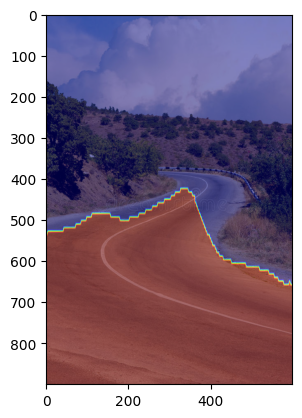

In [116]:
plt.imshow(image)
mask=cv2.resize(np.round(test[0]),image.shape[1::-1])
plt.imshow(mask,cmap='jet',alpha=0.5)

In [87]:
plt.imsave("test_image.png", image)
plt.imsave("test_mask.png",mask, cmap="gray")

In [97]:
load_model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 104, 184, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_141 (Conv2D)            (None, 104, 184, 32  896         ['input_12[0][0]']               
                                )                                                                 
                                                                                                  
 conv2d_142 (Conv2D)            (None, 104, 184, 32  9248        ['conv2d_141[0][0]']             
                                )                                                           